## 00 Importar librerias

In [1]:
import pandas as pd   #analisis de datos
#import missingno as msno  #visualiza datos nulos
from sklearn.model_selection import train_test_split   #nos permite dividir un dataset en dos bloques, típicamente bloques destinados al entrenamiento y validación del modelo
import matplotlib.pyplot as plt   #visualizar datos, hacer graficos
import seaborn as sns  # graficos
import numpy as np  #calculos numericos


## 01 Adjuntar Archivo - Recopilar datos

In [2]:
airbnb= "https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv"
data = pd.read_csv(airbnb)
total_data = (data).reset_index(inplace = False)
total_data.drop(columns = ["index"], inplace = True)
total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 02 Exploracion y Limpieza

In [3]:
# Obtener las dimensiones
total_data.shape

(48895, 16)

In [4]:
# Obtener información sobre tipos de datos y valores no nulos
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

* Existen un total de 48895 filas (propiedades para alquilar) y 16 columnas, de entre las que encontramos el objetivo a predecir, pudiera ser la variable *price*
* Las variables *last review y reviews_per_month* tienen 38843 instancias con valores, por lo que contendría más de 1000 valores nulos. 
* El resto de variables cuentan siempre con valor.
* Los datos cuentan con 10 características numéricas y 6 características categóricas.

### 2.1 Eliminar duplicados

In [5]:
# Eliminar duplicados 
total_data.drop("host_id", axis = 1).duplicated().sum()

#total_data = total_data.drop_duplicates()  #aplicar si encontramos duplicados.

np.int64(0)

In [ ]:
total_data = total_data.drop_duplicates(subset = total_data.columns.difference(["host_id"]))
print(total_data.shape)
total_data.head() # la informacion es igual no hay duplicados.

(48895, 12)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_category
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,Alto
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,Premium
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365,Alto
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,Medio
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,Medio


In [ ]:
# Verificar nuevamente si hay duplicados
if total_data.duplicated().sum():
    total_data = total_data.drop_duplicates()
print(total_data.shape)
total_data.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### 2.2 Eliminar Informacion Irrelevante

* las variables *id y host_id* son solo números de identificación únicos, No aportan información sobre el precio o características del alojamiento. Son útiles para rastrear registros pero no para predecir.
* las variables *name y host_name* son texto libre, no tienen relacion con algo importante a predecir.
* la variable *last_review* es una fecha específica. Aunque podría indicar qué tan activo está el alojamiento.

### variables importantes:

* neighbourhood_group, neighbourhood: ubicación.
* latitude, longitude: coordenadas geográficas.
* room_type: tipo de habitación.
* price: objetivo a predecir
* minimum_nights: mínimo de noches.
* number_of_reviews: número de reseñas. nuevos o viejos , caros o baratos
* reviews_per_month: frecuencia de reseñas. nuevos o viejos, caros o baratos
* calculated_host_listings_count: cuántos alojamientos tiene el anfitrión, personas o profesionales
* availability_365: días disponibles al año. solo temporada o negocio constante


In [8]:
#eliminar
total_data = total_data.drop(["id", "host_id", "name", "host_name", "last_review"], axis = 1, inplace = False)
#total_data.drop(["id", "host_id", "name", "host_name", "last_review"], axis = 1, inplace = True)
total_data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [24]:
total_data.info() # nos quedamos con 11 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   neighbourhood_group             48895 non-null  object  
 1   neighbourhood                   48895 non-null  object  
 2   latitude                        48895 non-null  float64 
 3   longitude                       48895 non-null  float64 
 4   room_type                       48895 non-null  object  
 5   price                           48895 non-null  int64   
 6   minimum_nights                  48895 non-null  int64   
 7   number_of_reviews               48895 non-null  int64   
 8   reviews_per_month               38843 non-null  float64 
 9   calculated_host_listings_count  48895 non-null  int64   
 10  availability_365                48895 non-null  int64   
 11  price_category                  48884 non-null  category
dtypes: category(1), fl

## 03 Análisis de variables univariante

Una variable univariante es un término estadístico que se emplea para referenciar un conjunto de observaciones de un atributo. Esto es, el análisis columna a columna del DataFrame. Para ello, debemos distinguir si una variable es categórica o numérica, ya que el cuerpo del análisis y las conclusiones que se pueden obtener serán distintas

### 3.1 Variable categórica

* neighbourhood_group.
* neighbourhood.
* room_type.
* price.
* number_of_reviews.
* availability_365.

se grafican en histogramas

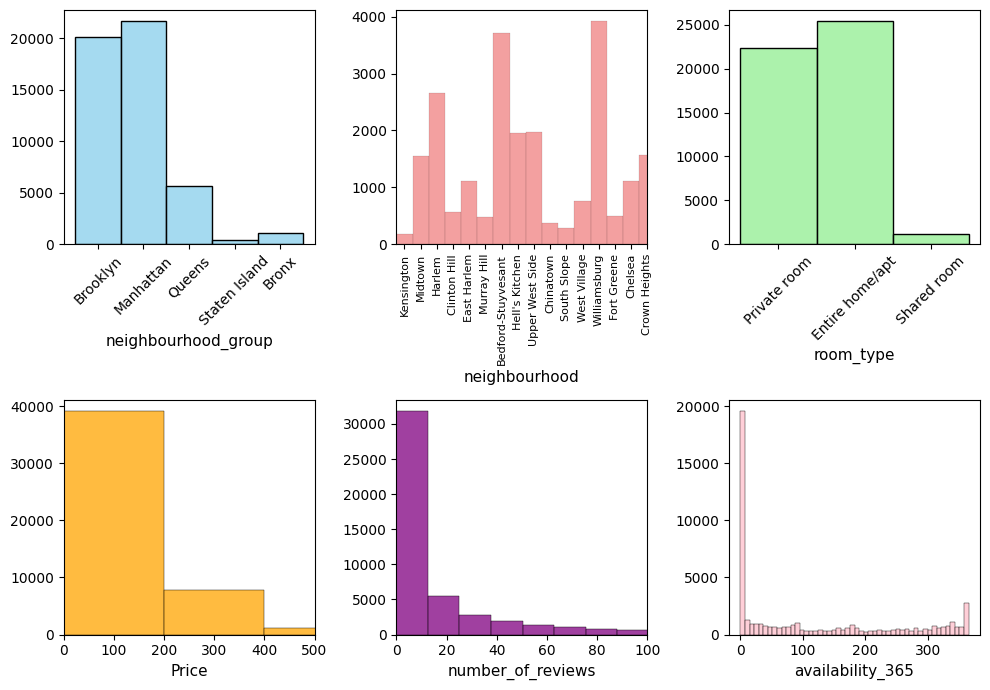

In [10]:
fig, axis = plt.subplots(2, 3, figsize = (10, 7))

# Crear un histograma múltiple
sns.histplot(ax=axis[0, 0], data=total_data, x="neighbourhood_group", color="skyblue").set(ylabel=None)
axis[0, 0].tick_params(axis='x', rotation=45, labelsize=10)
axis[0, 0].set_xlabel("neighbourhood_group", fontsize=11)

sns.histplot(ax=axis[0, 1], data=total_data, x="neighbourhood", color="lightcoral").set(ylabel=None)
axis[0, 1].tick_params(axis='x', rotation=90, labelsize=8)  # Rotación 90° porque hay muchos
axis[0, 1].set_xlabel("neighbourhood", fontsize=11)
axis[0, 1].set_xlim(-0.5, 15)  # Mostrar solo los primeros para legibilidad

sns.histplot(ax=axis[0, 2], data=total_data, x="room_type", color="lightgreen").set(ylabel=None)
axis[0, 2].tick_params(axis='x', rotation=45, labelsize=10)
axis[0, 2].set_xlabel("room_type", fontsize=11)

sns.histplot(ax=axis[1, 0], data=total_data, x="price", bins=50, color="orange").set(ylabel=None)
axis[1, 0].set_xlabel("Price", fontsize=11)
axis[1, 0].set_xlim(0, 500)  # Limitar outliers

sns.histplot(ax=axis[1, 1], data=total_data, x="number_of_reviews", bins=50, color="purple").set(ylabel=None)
axis[1, 1].set_xlabel("number_of_reviews", fontsize=11)
axis[1, 1].set_xlim(0, 100)  # Limitar outliers

sns.histplot(ax=axis[1, 2], data=total_data, x="availability_365", bins=50, color="pink").set(ylabel=None)
axis[1, 2].set_xlabel("availability_365", fontsize=11)
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

### Conclusiones
#### Neighbourhood_group :
Manhattan y Brooklyn son los que tienen mas alojamientos ya que son los que estan mas cerca de sitios turisticos, Queens tiene un nivel mas bajo y Bronx y Staten Island tienen muy pocos alojamientos.

#### Neighbourhood:
al reducir el numero de vecindarios a mostrar se puede observar que, Williamsburg, Bedford-Stuyvesant, Harlem están en el top de mayor alojamientos, siendo los otros vecindarios menos populares y con una distribución bastante desigual.

#### Room_type:


Entire home/apt,  es el tipo más común de alojamiento, Private room, es el segundo y Shared room es muy poco, la mayoria de los turistas prefieren privacidad.


#### Price: 

La mayoría de precios están entre $0 y $200, teniendo su mayoria entre $50 y $150 y algunos precios demasiado altos.

#### Number_of_reviews:

Los alojamientos tienen pocas reseñas y son pocos los que si tienen, puede ser  que los alojamientos son nuevos o simplemente no gustaron y no dejaron reseña

#### Availability_365:

Hay gran cantidad de alojamientos en el dato 0, lo que nos puede dar a entender que estan disponibles esporadicamente y los que estan disponibles todo el año puede ser por que son profesionales dedicados a este negocio.






### 3.2 Variable numérica

* price
* latitude 
* longitude 
* minimum_nights 
* number_of_reviews 
* calculated_host_listings_count



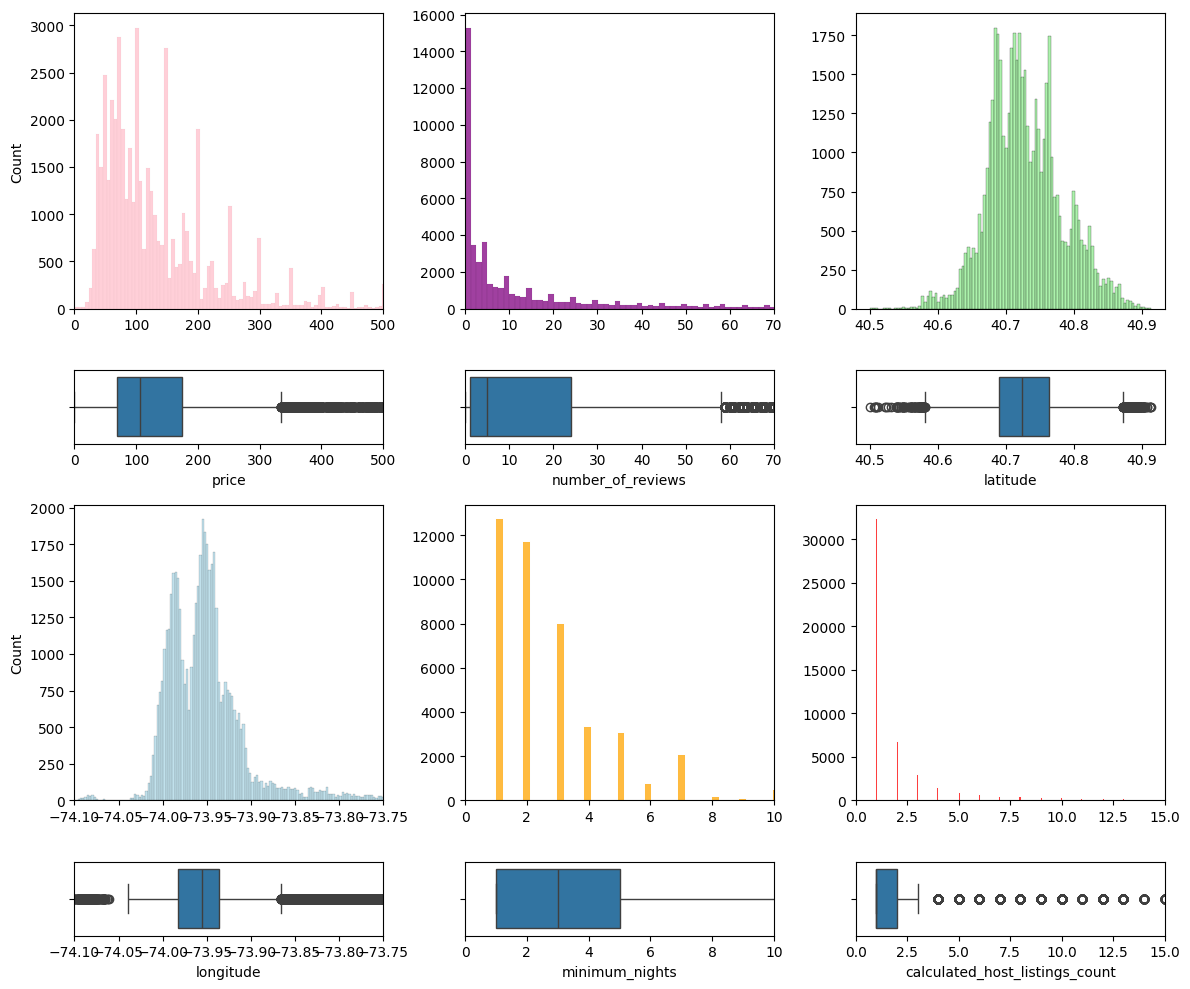

In [35]:


fig, axis = plt.subplots(4, 3, figsize=(12, 10), gridspec_kw={'height_ratios': [4, 1, 4, 1]})

# price
sns.histplot(ax=axis[0, 0], data=total_data, x="price", color= "pink")
axis[0, 0].set_xlim(0, 500)  # Limitar a 0-500 para ver mejor
axis[0, 0].set_xlabel(None)
sns.boxplot(ax=axis[1, 0], data=total_data, x="price")
axis[1, 0].set_xlim(0, 500)  # Limitar a 0-500
axis[1, 0].set_ylabel(None)

# number_of_reviews
sns.histplot(ax=axis[0, 1], data=total_data, x="number_of_reviews", color= "purple")
axis[0, 1].set_xlim(0, 70)  # Limitar a 0-100 para ver mejor
axis[0, 1].set_xlabel(None)
axis[0, 1].set_ylabel(None)
sns.boxplot(ax=axis[1, 1], data=total_data, x="number_of_reviews")
axis[1, 1].set_xlim(0, 70)
axis[1, 1].set_ylabel(None)

# latitude
sns.histplot(ax=axis[0, 2], data=total_data, x="latitude", color= "lightgreen")
axis[0, 2].set_xlabel(None)
axis[0, 2].set_ylabel(None)
sns.boxplot(ax=axis[1, 2], data=total_data, x="latitude")
axis[1, 2].set_ylabel(None)

# longitude
sns.histplot(ax=axis[2, 0], data=total_data, x="longitude", color= "lightblue")
axis[2, 0].set_xlim(-74.1, -73.75)  # Limitar a -74.1 a -73.75 para ver mejor
axis[2, 0].set_xlabel(None)
sns.boxplot(ax=axis[3, 0], data=total_data, x="longitude")
axis[3, 0].set_xlim(-74.1, -73.75)

# minimum_nights - LIMITANDO EL RANGO
sns.histplot(ax=axis[2, 1], data=total_data, x="minimum_nights", color= "orange")
axis[2, 1].set_xlim(0, 10)  # Limitar a 0-10 para ver mejor
axis[2, 1].set_xlabel(None)
axis[2, 1].set_ylabel(None)
sns.boxplot(ax=axis[3, 1], data=total_data, x="minimum_nights")
axis[3, 1].set_xlim(0, 10)  # Limitar a 0-10
axis[3, 1].set_ylabel(None)

# calculated_host_listings_count - LIMITANDO EL RANGO
sns.histplot(ax=axis[2, 2], data=total_data, x="calculated_host_listings_count", color= "red")
axis[2, 2].set_xlim(0, 15)  # Limitar a 0-15 para ver mejor
axis[2, 2].set_xlabel(None)
axis[2, 2].set_ylabel(None)
sns.boxplot(ax=axis[3, 2], data=total_data, x="calculated_host_listings_count")
axis[3, 2].set_xlim(0, 15)  # Limitar a 0-15
axis[3, 2].set_ylabel(None)

plt.tight_layout()
plt.show()

## 04 Análisis de variables multivariante

### 4.1 Analisis variable numerica - numerica

utilizaremos las variables 01 Price, 02 number_of_reviews y 03 calculated_host_listings_count, para realizar el analisis de correlacion

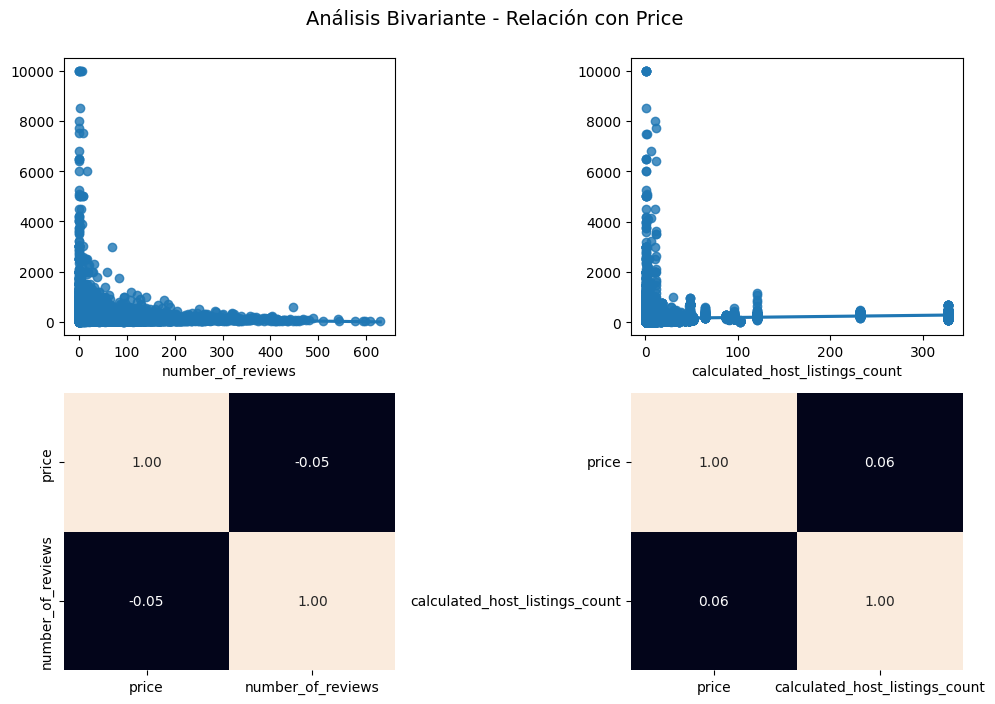

In [13]:
fig, axis = plt.subplots(2, 2, figsize = (10, 7))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = total_data, x = "number_of_reviews", y = "price").set(ylabel=None)
sns.heatmap(total_data[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = total_data, x = "calculated_host_listings_count", y = "price").set(ylabel=None)
sns.heatmap(total_data[["price", "calculated_host_listings_count"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

# Título general
fig.suptitle('Análisis Bivariante - Relación con Price', fontsize=14, y=1.00)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Conclusiones:
1. Price vs Number of Reviews
Diagrama de Dispersión:

Correlación negativa débil (aproximadamente -0.05 a -0.10)
La mayoría de puntos se concentran en la esquina inferior izquierda (precios bajos, pocas reseñas)
Hay una nube dispersa sin patrón lineal claro

Heatmap de Correlación:

Valor cercano a -0.05 o -0.10
Correlación muy débil/casi inexistente

* Las propiedades más caras tienden a tener MENOS reseñas (correlación negativa)

Posibles razones:

Propiedades caras se reservan menos frecuentemente
Son más exclusivas y tienen menos rotación de huéspedes
Menor accesibilidad = menos clientes = menos reseñas

* Las propiedades baratas tienen MÁS reseñas

Mayor rotación de huéspedes
Más accesibles = más reservas = más reseñas

2. Price vs Calculated Host Listings Count
Diagrama de Dispersión:

Correlación positiva débil (aproximadamente +0.05 a +0.15)
Mayoría de hosts tienen 1-5 propiedades
Algunos outliers con 50+ propiedades

Heatmap de Correlación:

Valor cercano a +0.07 o +0.12
Correlación débil pero positiva

Conclusiones:
* Hosts con MÁS propiedades tienden a cobrar precios LIGERAMENTE más altos

Son hosts profesionales/empresas que optimizan precios
Mejor gestión y conocimiento del mercado
Propiedades mejor equipadas/ubicadas

* Hosts individuales (1-2 propiedades) tienen precios más variables

Menos experiencia en pricing
Pueden subestimar o sobreestimar el valor



### 4.2 Analisis variable categórica - categórica

neighbourhood_group
room_type 
neighbourhood

relacion con la variante price

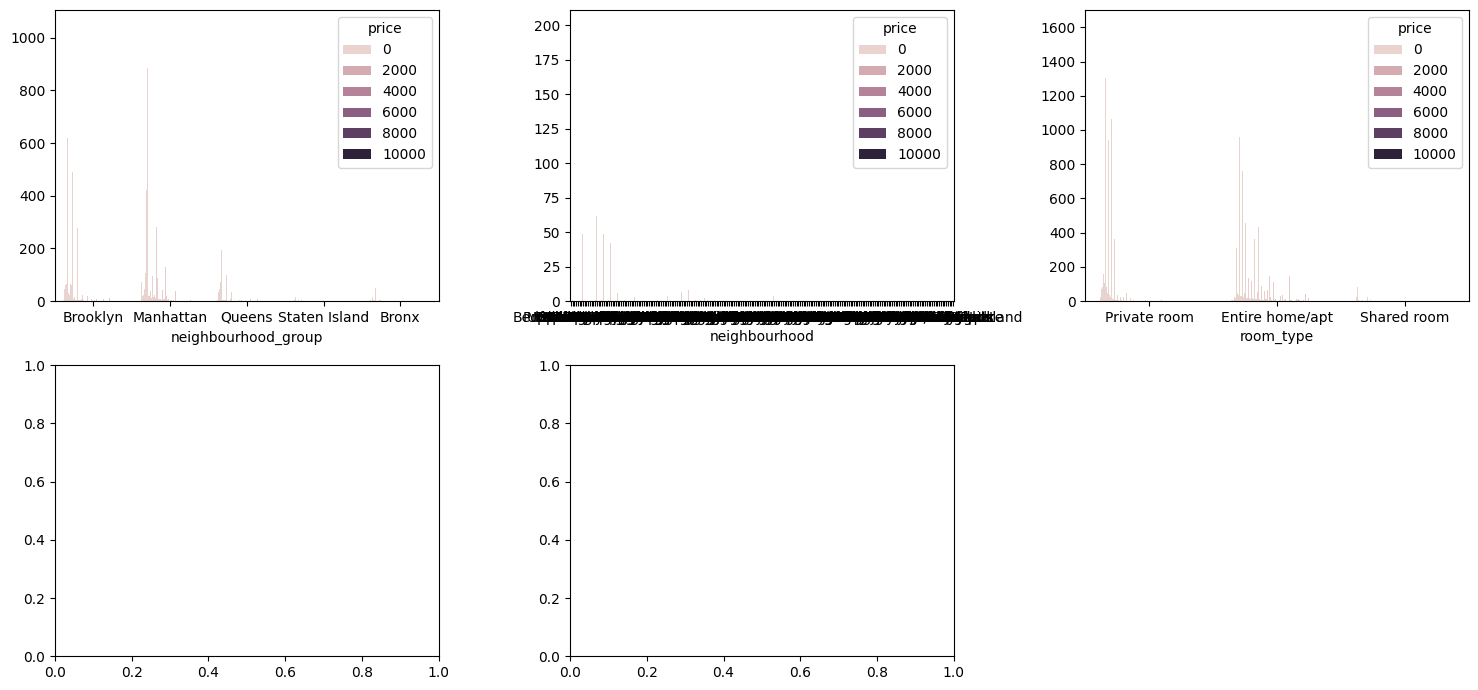

In [14]:
fig, axis = plt.subplots(2, 3, figsize = (15, 7))

sns.countplot(ax = axis[0, 0], data = total_data, x = "neighbourhood_group", hue = "price").set(ylabel = None)
sns.countplot(ax = axis[0, 1], data = total_data, x = "neighbourhood", hue = "price").set(ylabel = None)
sns.countplot(ax = axis[0, 2], data = total_data, x = "room_type", hue = "price").set(ylabel = None)


plt.tight_layout()
fig.delaxes(axis[1, 2])

plt.show()

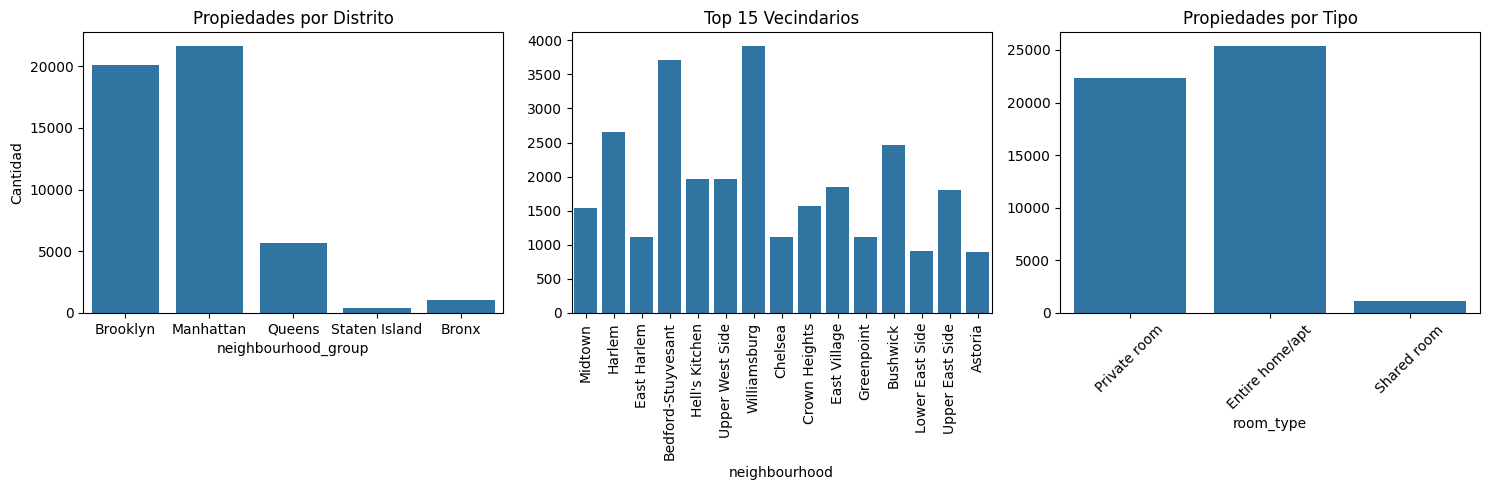

In [15]:
fig, axis = plt.subplots(1, 3, figsize=(15, 5))

# Countplot sin hue
sns.countplot(ax=axis[0], data=total_data, x="neighbourhood_group")
axis[0].set_title('Propiedades por Distrito')
axis[0].set_ylabel('Cantidad')

# neighbourhood - solo top 15
top_neighbourhoods = total_data['neighbourhood'].value_counts().head(15).index
data_filtered = total_data[total_data['neighbourhood'].isin(top_neighbourhoods)]
sns.countplot(ax=axis[1], data=data_filtered, x="neighbourhood")
axis[1].set_title('Top 15 Vecindarios')
axis[1].set_ylabel('')
axis[1].tick_params(axis='x', rotation=90)

sns.countplot(ax=axis[2], data=total_data, x="room_type")
axis[2].set_title('Propiedades por Tipo')
axis[2].set_ylabel('')
axis[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

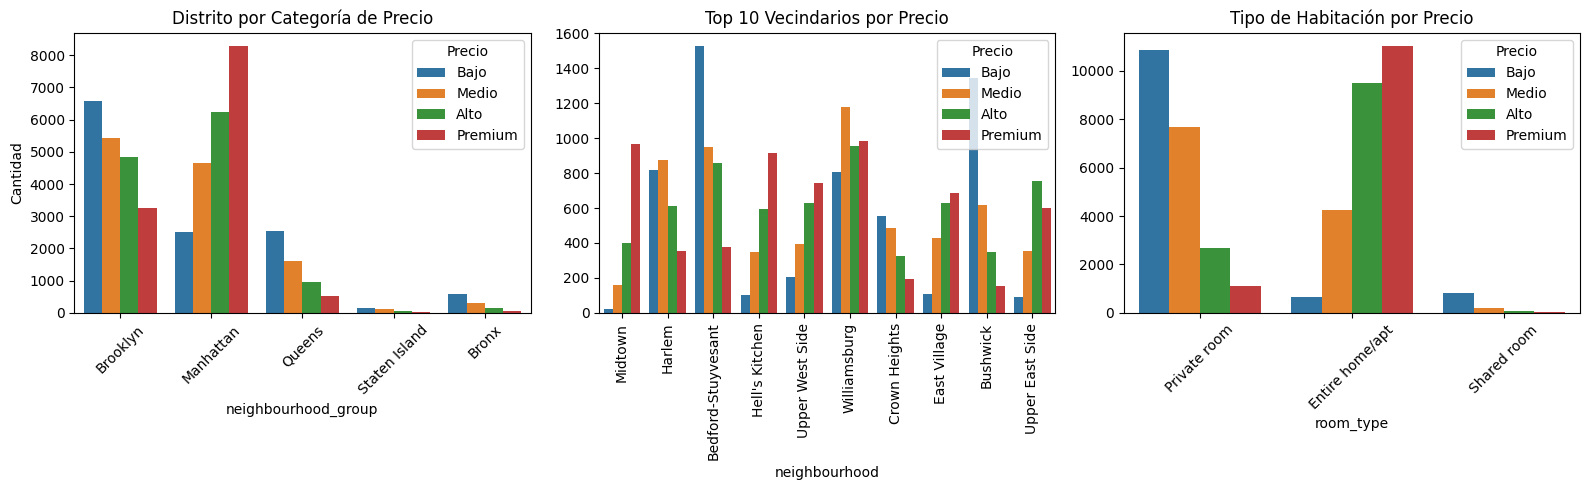

In [16]:
# Crear categoría de precio
total_data['price_category'] = pd.cut(total_data['price'], 
                                      bins=[0, 69, 106, 175, 10000],
                                      labels=['Bajo', 'Medio', 'Alto', 'Premium'])

fig, axis = plt.subplots(1, 3, figsize=(16, 5))

# neighbourhood_group con categoría de precio
sns.countplot(ax=axis[0], data=total_data, x="neighbourhood_group", 
              hue="price_category")
axis[0].set_title('Distrito por Categoría de Precio')
axis[0].set_ylabel('Cantidad')
axis[0].tick_params(axis='x', rotation=45)
axis[0].legend(title='Precio')

# Top 10 neighbourhoods
top_10 = total_data['neighbourhood'].value_counts().head(10).index
data_top10 = total_data[total_data['neighbourhood'].isin(top_10)]
sns.countplot(ax=axis[1], data=data_top10, x="neighbourhood", 
              hue="price_category")
axis[1].set_title('Top 10 Vecindarios por Precio')
axis[1].set_ylabel('')
axis[1].tick_params(axis='x', rotation=90)
axis[1].legend(title='Precio')

# room_type con categoría de precio
sns.countplot(ax=axis[2], data=total_data, x="room_type", 
              hue="price_category")
axis[2].set_title('Tipo de Habitación por Precio')
axis[2].set_ylabel('')
axis[2].tick_params(axis='x', rotation=45)
axis[2].legend(title='Precio')

plt.tight_layout()
plt.show()

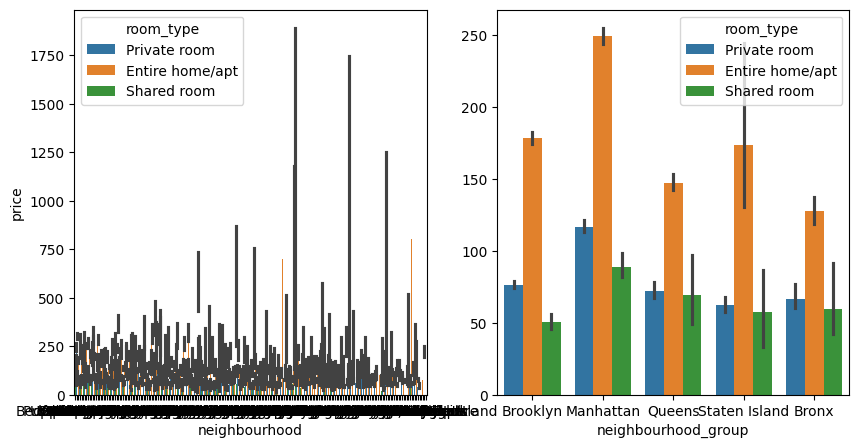

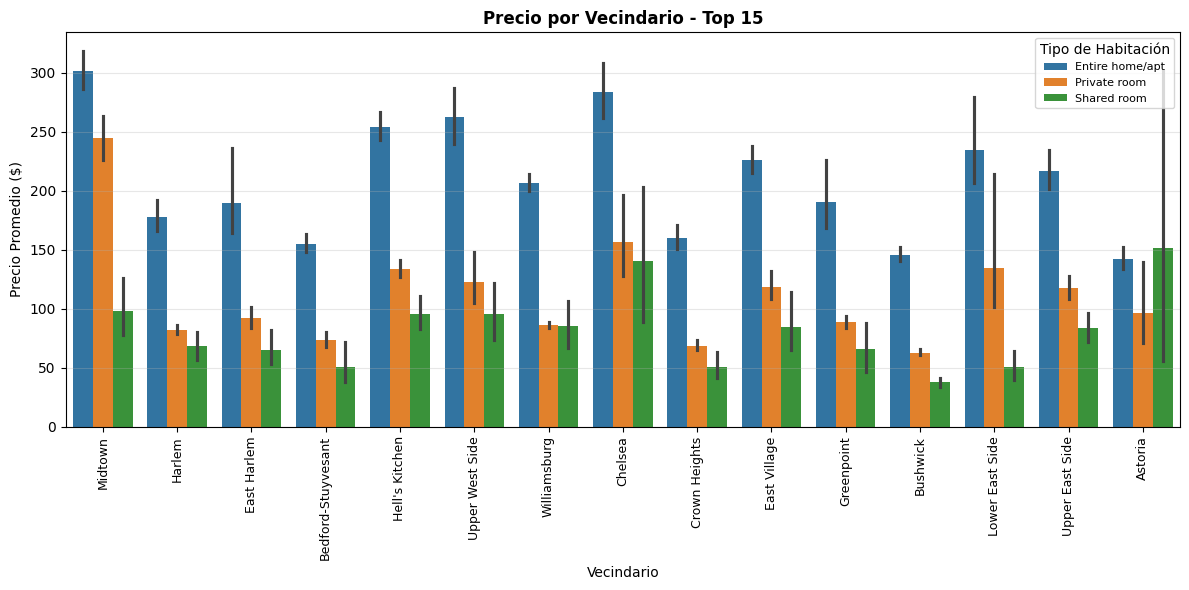

In [17]:
fig, axis = plt.subplots(figsize = (10, 5), ncols = 2)

sns.barplot(ax = axis[0], data = total_data, x = "neighbourhood", y = "price", hue = "room_type")
sns.barplot(ax = axis[1], data = total_data, x = "neighbourhood_group", y = "price", hue = "room_type").set(ylabel = None)


top_15 = total_data['neighbourhood'].value_counts().head(15).index
data_top15 = total_data[total_data['neighbourhood'].isin(top_15)]


fig, axis = plt.subplots(figsize=(12, 6))


sns.barplot(ax=axis, data=data_top15, x="neighbourhood", y="price", hue="room_type")
axis.tick_params(axis='x', rotation=90, labelsize=9)
axis.set_title('Precio por Vecindario - Top 15', fontsize=12, fontweight='bold')
axis.set_xlabel('Vecindario', fontsize=10)
axis.set_ylabel('Precio Promedio ($)', fontsize=10)
axis.legend(title='Tipo de Habitación', fontsize=8)
axis.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Conclusiones
1. Concentración Geográfica del Mercado

Los Top 15 vecindarios concentran una gran parte de toda la oferta
Brooklyn y Manhattan dominan la oferta (especialmente Williamsburg, Harlem, Bushwick)
Hay clara segregación por precio entre vecindarios

✅ 2. Microubicación Importa MUCHO

No solo importa el distrito (Manhattan vs Brooklyn)
El vecindario específico dentro del distrito es crucial
Ejemplo: Harlem (Manhattan) puede ser más barato que Williamsburg (Brooklyn)
Implicación: Para modelos predictivos, neighbourhood puede ser más importante que neighbourhood_group

### 4.3 Análisis numérico-categórico (completo)

* price
* latitude 
* longitude 
* minimum_nights 
* number_of_reviews 
* calculated_host_listings_count
* reviews_per_month

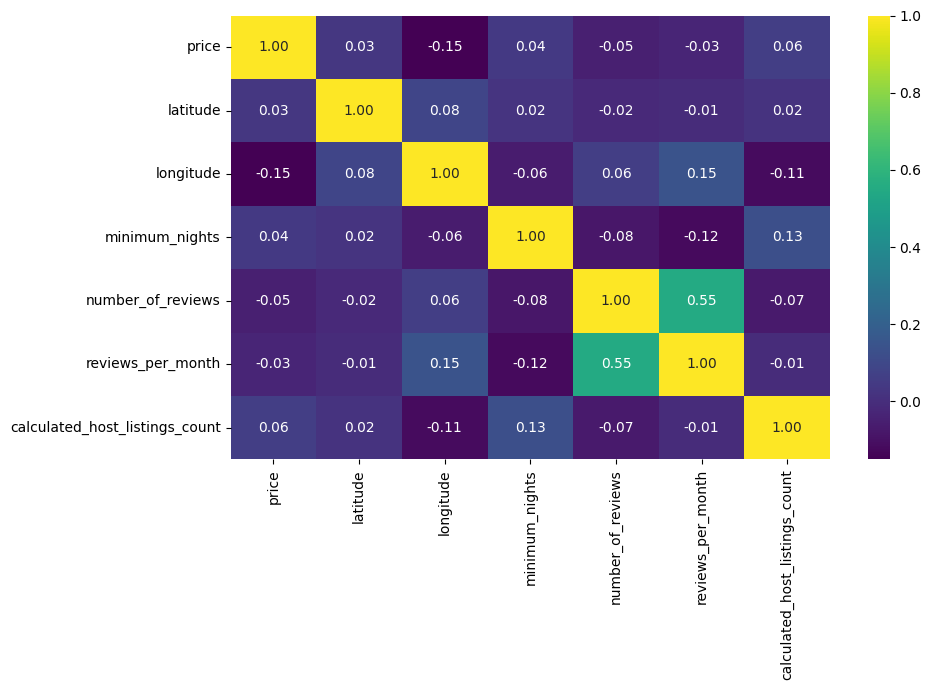

In [18]:
cols_num = ["price", "latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count"]  # todas numéricas
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(total_data[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()